# Testing the calibration root finder (Hof project)

This notebook tests the generic root finder added to `run_model_Hof.py` (commit `62bb567b`)
**without running a disc-evolution simulation**. No time stepping, HDF5 output or chemistry runs.

The functions tested only build the **initial** disc (grid, EOS/temperature, Sigma, one
radial-velocity evaluation), so each solve takes about a second:

| Function (in `run_model_Hof.py`) | What it does |
|---|---|
| `_build_grid_star_kappa(config)` | grid (AU), star (Msun, Rsun, K), opacity function (cm$^2$/g) |
| `evaluate_initial_disc(grid, star, p, eos_params, kappa)` | forward model: parameters `p` → inner accretion rate `Mdot` at `R_c[0]` (Msun/yr) |
| `solve_initial_disc(grid, star, config, kappa)` | root-finds `config['calibration']['solve_for']` so that `Mdot` = `config['disc']['Mdot']` |
| `_SOLVABLE_PARAMS` | which parameters can be solved for, their config location, search scale and default bracket |

Importing `run_model_Hof` has no side effects (the run only starts under `if __name__ == "__main__"`).

**Nothing is written to disk by this notebook:** no figures are saved, no HDF5, no config logs.
Plots are shown inline only.

### Sections
1. Setup: load the config, build grid/star/kappa
2. Helpers: pretty-printing of each solve
3. **Round-trip test**: known-answer check for each of the 6 parameters
4. **Solve the config's actual target** (Mdot = config value) for each parameter, one at a time
5. Cross-check against the old damped alpha loop (`disc_setup.setup_disc`)
6. Failure path: an unreachable target must raise
7. **Visualization**: Mdot vs each parameter, with the target and the solved values

## 1. Setup

`CONFIG_PATH` can be changed to test another config. The default is `DiscConfig_Hof_Ben.json`.

**Note on the Ben config:** its `grid.type` is `"winds-psi"`. `solve_initial_disc` never reads
`grid.type`, so the root finder is unaffected. However, `disc_setup.setup_disc` (the path
`run_model()` takes when the config has **no** `"calibration"` section) only supports
`"winds-alpha"` and raises `ValueError` otherwise. So running the Ben config through
`run_model_Hof.py` *without* a calibration section would currently fail at the disc setup.
Section 5 works around this on an in-memory copy only. The JSON file is not changed.

In [50]:
import sys, os, json, copy
import numpy as np
import matplotlib.pyplot as plt

# run_model_Hof.py and disc_setup.py live one directory up (example/StartHere/)
sys.path.insert(0, os.path.abspath('..'))

from run_model_Hof import (
    _build_grid_star_kappa,   # config -> grid, star, kappa
    evaluate_initial_disc,    # forward model: parameters -> Mdot at R_c[0] (Msun/yr)
    solve_initial_disc,       # the root finder under test
    _SOLVABLE_PARAMS,         # name -> (config section, key, 'log'/'linear', default bracket)
)
from disc_setup import setup_disc   # old damped fixed-point alpha solver (reference for section 5)

# ---- config to test (change this to test another config) ----
CONFIG_PATH = '../config/DiscConfig_Hof_Ben.json'
with open(CONFIG_PATH) as f:
    config = json.load(f)
CONFIG_NAME = os.path.basename(CONFIG_PATH)

# grid.Rc in AU; star M in Msun, R in Rsun, T_eff in K; kappa(rho, T) in cm^2/g
grid, star, kappa = _build_grid_star_kappa(config)

# Units of each solvable parameter (from the comments on _SOLVABLE_PARAMS in run_model_Hof.py)
UNITS = {
    'alpha':  'dimensionless',   # TOTAL alpha = alpha_SS * (1 + psi_DW)
    'M':      'Msun',            # disc mass
    'Rd':     'AU',              # characteristic radius
    'gamma':  'dimensionless',   # Sigma power-law index (< 2)
    'psi_DW': 'dimensionless',   # alpha_DW / alpha_SS
    'e_rad':  'dimensionless',   # fraction of accretion heating radiated (< 1)
}
PARAMS = list(_SOLVABLE_PARAMS)   # ['alpha', 'M', 'Rd', 'gamma', 'psi_DW', 'e_rad']

# p0 = the config's own parameter set, in the units above (same dict layout that
# solve_initial_disc builds internally and evaluate_initial_disc expects)
p0 = {
    'alpha':  config['disc']['alpha'],
    'M':      config['disc']['M'],
    'Rd':     config['disc']['Rd'],
    'gamma':  config['disc']['gamma'],
    'psi_DW': config['winds']['psi_DW'],
    'e_rad':  config['winds']['e_rad'],
}
if isinstance(p0['alpha'], str):
    raise ValueError(f"This notebook needs a numeric disc.alpha in the config (got {p0['alpha']!r}): "
                     "the round-trip test uses the config values as the known 'true' answer.")
MDOT_TARGET = config['disc']['Mdot']   # Msun/yr

print(f"Config: {CONFIG_NAME}   (grid.type = {config['grid']['type']!r})")
print(f"Grid  : {config['grid']['nr']} cells, R_c[0] = {grid.Rc[0]:.4g} AU ... R_c[-1] = {grid.Rc[-1]:.4g} AU")
print(f"EOS   : {config['eos']['type']}, opacity {config['eos']['opacity']}, Tmax = {config['eos'].get('Tmax')} K")
print(f"Target Mdot = {MDOT_TARGET:.3e} Msun/yr")
print("Config parameter values:")
for k in PARAMS:
    print(f"   {k:7s} = {p0[k]:<10.4g} {UNITS[k]}")

# Mdot the config's own parameters actually give (no solve) -- how far from the target we start
Mdot_cfg = evaluate_initial_disc(grid, star, p0, config['eos'], kappa)['Mdot']   # Msun/yr
print(f"\nMdot(R_c[0]) at these values (no solve) = {Mdot_cfg:.4e} Msun/yr "
      f"= {Mdot_cfg / MDOT_TARGET:.3g} x target")

Config: DiscConfig_Hof_Ben.json   (grid.type = 'winds-psi')
Grid  : 1000 cells, R_c[0] = 0.1101 AU ... R_c[-1] = 999 AU
EOS   : IrradiatedEOS, opacity Zhu2012, Tmax = 1500.0 K
Target Mdot = 1.000e-08 Msun/yr
Config parameter values:
   alpha   = 2.3e-05    dimensionless
   M       = 0.1        Msun
   Rd      = 50         AU
   gamma   = 1          dimensionless
   psi_DW  = 10         dimensionless
   e_rad   = 0.9        dimensionless

Mdot(R_c[0]) at these values (no solve) = 9.2165e-10 Msun/yr = 0.0922 x target


## 2. Helpers

* `bracket_of(name)`: the default search range in `_SOLVABLE_PARAMS`, in the parameter's own units.
* `calib_config(name, guess, Mdot_target)`: a deep copy of `config` with a `"calibration"` section
  and with the free parameter set to `guess`. The config value of the solved parameter is only
  used as the initial guess.
* `print_solve(...)`: prints one block per solve with the final solved value and its units.

In [51]:
def bracket_of(name):
    """Default [lo, hi] search range for `name`, in the parameter's own units (Rd hi=None -> outermost cell)."""
    lo, hi = _SOLVABLE_PARAMS[name][3]
    if hi is None:
        hi = float(grid.Rc[-1])   # AU
    return lo, hi


def calib_config(name, guess, Mdot_target, **calib_extra):
    """
    Deep copy of `config` set up to solve for `name`:
      - config[section][key] = guess    (only the INITIAL GUESS; used to pick among roots)
      - config['disc']['Mdot'] = Mdot_target  (Msun/yr)
      - config['calibration'] = {'solve_for': name, **calib_extra}
    The original `config` is not modified.
    """
    section, key = _SOLVABLE_PARAMS[name][:2]
    c = copy.deepcopy(config)
    c[section][key] = guess
    c['disc']['Mdot'] = Mdot_target
    c['calibration'] = {'solve_for': name, **calib_extra}
    return c


def print_solve(name, guess, Mdot_target, res=None, true_value=None, status='', error=None):
    """Print one solve: target, guess, SOLVED VALUE (with units), achieved Mdot, resulting disc, cost."""
    u = UNITS[name]
    print(f"=== solve_for = {name} " + "=" * (50 - len(name)))
    print(f"  target Mdot    : {Mdot_target:.4e} Msun/yr")
    print(f"  guess          : {guess:<14.6g} ({u})")
    if res is not None:
        info = res['info']
        print(f"  SOLVED VALUE   : {info['value']:<14.6g} ({u})")
    if true_value is not None:
        print(f"  true value     : {true_value:<14.6g} ({u})   <- known answer (round-trip)")
    if res is not None:
        print(f"  achieved Mdot  : {info['Mdot']:.4e} Msun/yr   (|Mdot/target - 1| = {info['Mdot_relerr']:.1e})")
        print(f"  resulting disc : alpha = {res['alpha']:.4e}, alpha_SS = {res['alpha_SS']:.4e}, "
              f"lambda_DW = {res['lambda_DW']:.4g}   (all dimensionless)")
        print(f"  cost           : {info['n_evals']} forward-model evaluations, "
              f"{info['n_roots']} root(s) found in the bracket")
    if error is not None:
        print(f"  solver raised  : {type(error).__name__}: {error}")
    if status:
        print(f"  -> {status}")
    print()

## 3. Round-trip test (known answer)

For each parameter:
1. Compute `Mdot0` = the Mdot the config's own parameters `p0` give (Msun/yr). This is the
   **target**, so the correct answer is known: the config value `p0[name]`.
2. Move the free parameter away from its true value to use as the guess
   (×3 for log-scaled parameters, ±0.3 for linear ones).
3. Solve, and check that the solved value equals `p0[name]` to within a relative tolerance of `RT_TOL`.

Status:
* **PASS**: the solved value matches the true value.
* **FAIL**: it converged to something else (e.g. a different root if Mdot is not monotonic), or it raised unexpectedly.
* **SKIP**: the solver correctly refused because Mdot at `R_c[0]` does not depend on this parameter
  (e.g. `e_rad` when the inner cells sit at the `Tmax` cap). This is the designed behaviour, not a bug.

In [52]:
RT_TOL = 1e-4   # max allowed |solved/true - 1| (dimensionless)

# Target = what the config's own parameters give, so the "true" answer is p0[name]
Mdot0 = evaluate_initial_disc(grid, star, p0, config['eos'], kappa)['Mdot']   # Msun/yr
print(f"Round-trip target Mdot0 = {Mdot0:.4e} Msun/yr (Mdot of the config's own parameters)\n")

# Messages solve_initial_disc raises when Mdot is insensitive to the parameter (-> SKIP, not FAIL)
INSENSITIVE_MARKERS = ('does not depend on', 'ALL give Mdot')

roundtrip = []   # one dict per parameter, for the summary table
for name in PARAMS:
    true_val = float(p0[name])
    scale = _SOLVABLE_PARAMS[name][2]
    lo, hi = bracket_of(name)
    # perturbed initial guess, kept inside the bracket
    if scale == 'log':
        guess = true_val * 3.0 if true_val * 3.0 < hi else true_val / 3.0
    else:
        guess = true_val + 0.3 if true_val + 0.3 < hi else true_val - 0.3

    row = {'name': name, 'true': true_val, 'guess': guess, 'solved': np.nan,
           'relerr': np.nan, 'n_evals': '', 'n_roots': '', 'status': ''}
    res, err = None, None
    try:
        res = solve_initial_disc(grid, star, calib_config(name, guess, Mdot0), kappa)
        solved = res['info']['value']
        relerr = abs(solved / true_val - 1) if true_val != 0 else abs(solved)
        row.update(solved=solved, relerr=relerr, n_evals=res['info']['n_evals'],
                   n_roots=res['info']['n_roots'], status='PASS' if relerr < RT_TOL else 'FAIL')
    except RuntimeError as e:
        err = e
        row['status'] = 'SKIP' if any(m in str(e) for m in INSENSITIVE_MARKERS) else 'FAIL'
    except Exception as e:   # anything else is a genuine bug
        err = e
        row['status'] = 'FAIL'
    roundtrip.append(row)
    print_solve(name, guess, Mdot0, res=res, true_value=true_val, status=row['status'], error=err)

# ---- summary table ----
hdr = f"{'param':7s} {'units':13s} {'true':>11s} {'guess':>11s} {'solved':>13s} {'rel.err':>9s} {'evals':>6s} {'roots':>6s}  status"
print(hdr)
print('-' * len(hdr))
for r in roundtrip:
    print(f"{r['name']:7s} {UNITS[r['name']]:13s} {r['true']:11.4g} {r['guess']:11.4g} "
          f"{r['solved']:13.7g} {r['relerr']:9.1e} {str(r['n_evals']):>6s} {str(r['n_roots']):>6s}  {r['status']}")
n_fail = sum(r['status'] == 'FAIL' for r in roundtrip)
print(f"\n{'ALL OK' if n_fail == 0 else f'{n_fail} FAILURE(S)'} "
      f"({sum(r['status'] == 'PASS' for r in roundtrip)} pass, {sum(r['status'] == 'SKIP' for r in roundtrip)} skip)")

Round-trip target Mdot0 = 9.2165e-10 Msun/yr (Mdot of the config's own parameters)

Calibration: alpha = 2.3e-05 (guess 6.9e-05) -> Mdot = 9.2165e-10 Msun/yr (rel. err 1.2e-15, 36 evaluations)
=== solve_for = alpha =============================================
  target Mdot    : 9.2165e-10 Msun/yr
  guess          : 6.9e-05        (dimensionless)
  SOLVED VALUE   : 2.3e-05        (dimensionless)
  true value     : 2.3e-05        (dimensionless)   <- known answer (round-trip)
  achieved Mdot  : 9.2165e-10 Msun/yr   (|Mdot/target - 1| = 1.2e-15)
  resulting disc : alpha = 2.3000e-05, alpha_SS = 2.0909e-06, lambda_DW = 4.846   (all dimensionless)
  cost           : 36 forward-model evaluations, 1 root(s) found in the bracket
  -> PASS

Calibration: M = 0.1 (guess 0.3) -> Mdot = 9.2165e-10 Msun/yr (rel. err 0.0e+00, 32 evaluations)
=== solve_for = M =================================================
  target Mdot    : 9.2165e-10 Msun/yr
  guess          : 0.3            (Msun)
  SOLVED VALU

## 4. Solve the config's actual target

This time the target is the config's real `Mdot` (Msun/yr), and each parameter's config value is
its initial guess. For each parameter **on its own** (all others held at their config values),
this answers: *what value would it need to take to give the target Mdot?*

These are the values `run_model_Hof.py` would use if the config had
`"calibration": {"solve_for": <name>}`. The solved values are kept in `solved_actual` for the plot in section 7.

In [53]:
solved_actual = {}   # name -> solved value (parameter's own units), or None if unreachable/insensitive
for name in PARAMS:
    guess = float(p0[name])
    res, err = None, None
    try:
        res = solve_initial_disc(grid, star, calib_config(name, guess, MDOT_TARGET), kappa)
        solved_actual[name] = res['info']['value']
    except RuntimeError as e:
        err = e
        solved_actual[name] = None
    print_solve(name, guess, MDOT_TARGET, res=res, error=err)

print(f"SUMMARY -- with everything else fixed at the {CONFIG_NAME} values, "
      f"to give Mdot = {MDOT_TARGET:.3e} Msun/yr:")
for name in PARAMS:
    v = solved_actual[name]
    if v is None:
        print(f"   {name:7s}: no solution (see the solver message above)")
    else:
        print(f"   {name:7s} would need to be {v:<12.6g} {UNITS[name]:13s} (config value {p0[name]:.4g})")

Calibration: alpha = 0.000249552 (guess 2.3e-05) -> Mdot = 1.0000e-08 Msun/yr (rel. err 6.7e-16, 36 evaluations)
=== solve_for = alpha =============================================
  target Mdot    : 1.0000e-08 Msun/yr
  guess          : 2.3e-05        (dimensionless)
  SOLVED VALUE   : 0.000249552    (dimensionless)
  achieved Mdot  : 1.0000e-08 Msun/yr   (|Mdot/target - 1| = 6.7e-16)
  resulting disc : alpha = 2.4955e-04, alpha_SS = 2.2687e-05, lambda_DW = 4.846   (all dimensionless)
  cost           : 36 forward-model evaluations, 1 root(s) found in the bracket

=== solve_for = M =================================================
  target Mdot    : 1.0000e-08 Msun/yr
  guess          : 0.1            (Msun)
  solver raised  : RuntimeError: calibration: no M in [1e-05, 1] gives Mdot = 1.000e-08 Msun/yr with the other parameters fixed. Reachable range: [2.437e-14, 9.217e-09] Msun/yr. Widen calibration.bracket, or change another parameter.

Calibration: Rd = 4.56995 (guess 50) -> Mdot =

## 5. Cross-check against the old damped alpha loop

Without a `"calibration"` section, `run_model()` calls `disc_setup.setup_disc()`. That runs
`winds_alpha_disc()`, which applies 100 damped fixed-point updates
`alpha <- 0.5 (alpha + alpha * Mdot_target / Mdot)`. When solving for alpha, the new root finder
should agree with it.

The damped loop returns alpha **after** its last update, so its alpha is only as converged as those
100 iterations allow. The Mdot each alpha actually gives is also printed.

`setup_disc` only accepts `grid.type = "winds-alpha"`, so it is given an in-memory copy with that
set. The JSON file is not changed.

In [54]:
# ---- old path: damped fixed-point loop (the same call run_model() makes) ----
cfg_old = copy.deepcopy(config)
cfg_old['grid']['type'] = 'winds-alpha'   # in-memory only; setup_disc rejects 'winds-psi'
_, _, _, alpha_old, alpha_SS_old, _ = setup_disc(grid, star, cfg_old, kappa)   # total alpha, dimensionless

# ---- new path: generic root finder, solve_for = 'alpha', same target and guess ----
res_new = solve_initial_disc(grid, star, calib_config('alpha', float(p0['alpha']), MDOT_TARGET), kappa)
alpha_new = res_new['alpha']   # total alpha, dimensionless

# Mdot each alpha actually gives (Msun/yr), via the same forward model
Mdot_old = evaluate_initial_disc(grid, star, {**p0, 'alpha': alpha_old}, config['eos'], kappa)['Mdot']
Mdot_new = res_new['info']['Mdot']

print(f"Target Mdot                 : {MDOT_TARGET:.4e} Msun/yr")
print(f"Old damped loop  alpha      : {alpha_old:.8e}  -> Mdot = {Mdot_old:.6e} Msun/yr "
      f"(|Mdot/target - 1| = {abs(Mdot_old / MDOT_TARGET - 1):.1e})")
print(f"New root finder  alpha      : {alpha_new:.8e}  -> Mdot = {Mdot_new:.6e} Msun/yr "
      f"(|Mdot/target - 1| = {abs(Mdot_new / MDOT_TARGET - 1):.1e})")
print(f"|alpha_new / alpha_old - 1| : {abs(alpha_new / alpha_old - 1):.2e}")
print(f"alpha_SS (old / new)        : {alpha_SS_old:.6e} / {res_new['alpha_SS']:.6e}")

Calibration: alpha = 0.000249552 (guess 2.3e-05) -> Mdot = 1.0000e-08 Msun/yr (rel. err 6.7e-16, 36 evaluations)
Target Mdot                 : 1.0000e-08 Msun/yr
Old damped loop  alpha      : 2.49552358e-04  -> Mdot = 1.000000e-08 Msun/yr (|Mdot/target - 1| = 2.2e-16)
New root finder  alpha      : 2.49552358e-04  -> Mdot = 1.000000e-08 Msun/yr (|Mdot/target - 1| = 6.7e-16)
|alpha_new / alpha_old - 1| : 6.66e-16
alpha_SS (old / new)        : 2.268658e-05 / 2.268658e-05


## 6. Failure path: unreachable target

The target Mdot = 1e-2 Msun/yr is set while solving for `psi_DW` over its default bracket. The
solver should **raise** `RuntimeError` and report the reachable Mdot range, rather than return a
meaningless value.

In [55]:
MDOT_UNREACHABLE = 1e-2   # Msun/yr, far above anything a 0.1 Msun disc gives
try:
    bad = solve_initial_disc(grid, star, calib_config('psi_DW', float(p0['psi_DW']), MDOT_UNREACHABLE), kappa)
    print(f"FAIL: solver returned psi_DW = {bad['info']['value']:.4g} instead of raising")
except RuntimeError as e:
    ok = 'Reachable range' in str(e)
    print(f"{'PASS' if ok else 'FAIL (raised, but without the reachable range)'}: solver raised as expected:\n  {e}")

PASS: solver raised as expected:
  calibration: no psi_DW in [0.001, 1000] gives Mdot = 1.000e-02 Msun/yr with the other parameters fixed. Reachable range: [8.399e-10, 1.748e-09] Msun/yr. Widen calibration.bracket, or change another parameter.


## 7. Visualization: Mdot vs each parameter

For each parameter (others fixed at the config values), the plot shows Mdot at `R_c[0]` across the
solver's default search bracket. Each panel has:
* **black line**: Mdot(parameter), computed with the same forward model the solver uses
  (`evaluate_initial_disc`), in Msun/yr
* **red dashed line**: the target Mdot (config value)
* **red star**: the solved value from section 4, annotated with its value and units.
  It should sit on the intersection of the curve and the target line.
* **blue dotted line**: the config value of that parameter
* **grey shading**: the forward model failed (nan), or Mdot is flat in the parameter
  (e.g. the inner cells are at the `Tmax` cap). A flat region means Mdot does not constrain that parameter.

If Mdot crosses the target more than once, the solver picks the crossing closest to the guess (the
config value) and prints a warning.

Figures are shown inline only and not saved.

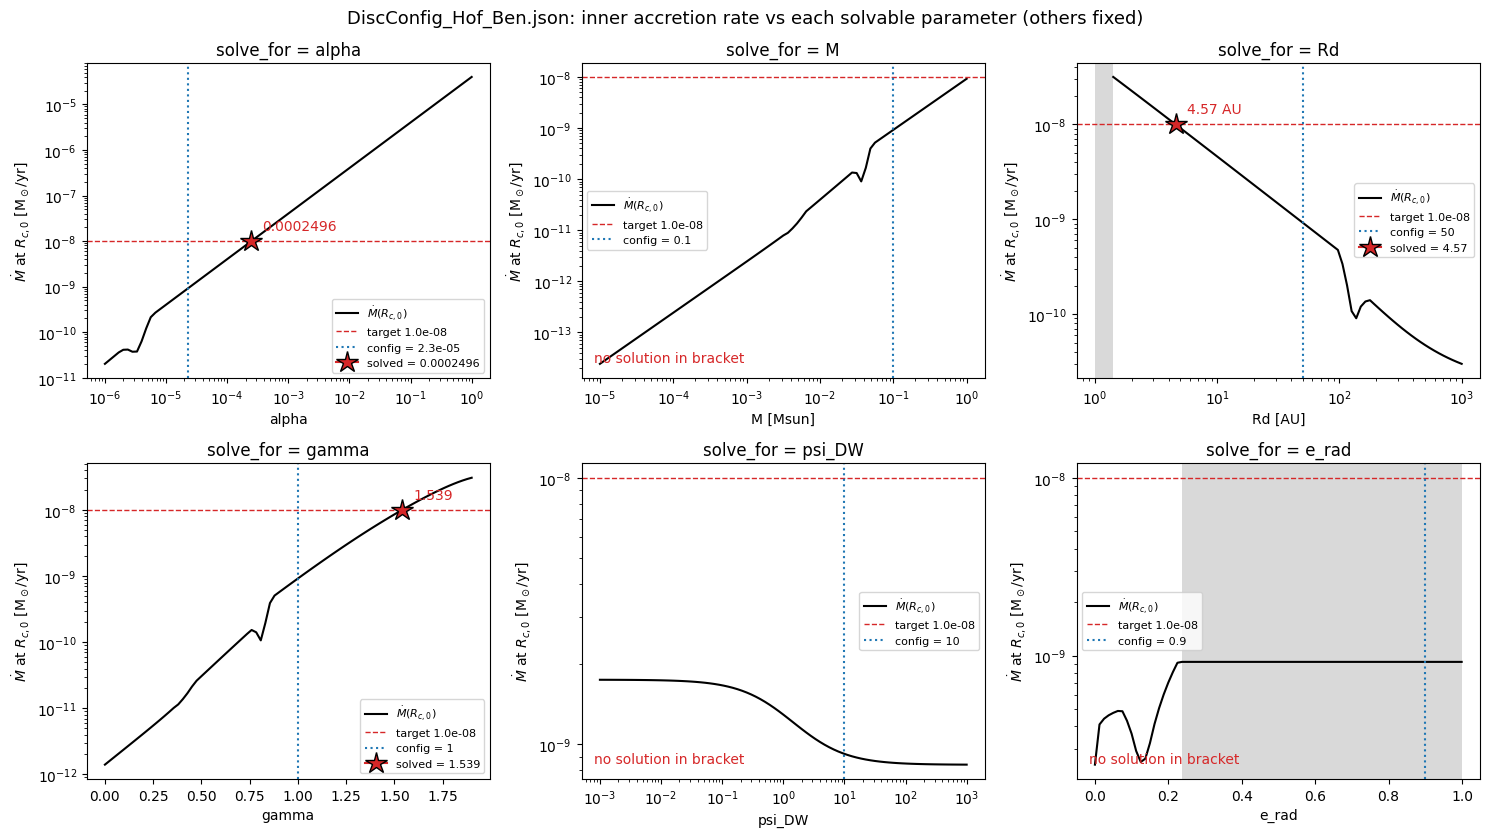

In [56]:
N_PLOT = 81   # points per curve

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, name in zip(axes.flat, PARAMS):
    scale = _SOLVABLE_PARAMS[name][2]
    lo, hi = bracket_of(name)
    vals = np.logspace(np.log10(lo), np.log10(hi), N_PLOT) if scale == 'log' else np.linspace(lo, hi, N_PLOT)

    # forward model at each value (nan if the EOS fails at extreme values, as in the solver's scan)
    mdots = np.full(N_PLOT, np.nan)   # Msun/yr
    with np.errstate(all='ignore'):
        for i, v in enumerate(vals):
            try:
                m = evaluate_initial_disc(grid, star, {**p0, name: float(v)}, config['eos'], kappa)['Mdot']
                mdots[i] = m if (np.isfinite(m) and m > 0) else np.nan
            except (RuntimeError, ValueError, FloatingPointError, ZeroDivisionError):
                pass

    # grey shading: nan, or Mdot flat between neighbours (|dlog10 Mdot| < 1e-10)
    for i in range(N_PLOT - 1):
        a, b = mdots[i], mdots[i + 1]
        if not (np.isfinite(a) and np.isfinite(b)) or abs(np.log10(b / a)) < 1e-10:
            ax.axvspan(vals[i], vals[i + 1], color='0.85', lw=0, zorder=0)

    ax.plot(vals, mdots, 'k-', lw=1.5, label=r'$\dot M(R_{c,0})$')
    ax.axhline(MDOT_TARGET, color='C3', ls='--', lw=1, label=f'target {MDOT_TARGET:.1e}')
    ax.axvline(p0[name], color='C0', ls=':', lw=1.5, label=f'config = {p0[name]:.3g}')

    v = solved_actual[name]
    if v is not None:
        ax.plot([v], [MDOT_TARGET], marker='*', ms=16, color='C3', mec='k', zorder=5,
                label=f'solved = {v:.4g}')
        ax.annotate(f'{v:.4g} {UNITS[name] if UNITS[name] != "dimensionless" else ""}'.strip(),
                    (v, MDOT_TARGET), textcoords='offset points', xytext=(8, 8), fontsize=10, color='C3')
    else:
        ax.text(0.03, 0.05, 'no solution in bracket', transform=ax.transAxes, color='C3', fontsize=10)

    if scale == 'log':
        ax.set_xscale('log')
    ax.set_yscale('log')
    unit_lbl = '' if UNITS[name] == 'dimensionless' else f' [{UNITS[name]}]'
    ax.set_xlabel(f'{name}{unit_lbl}')
    ax.set_ylabel(r'$\dot M$ at $R_{c,0}$ [M$_\odot$/yr]')
    ax.set_title(f'solve_for = {name}')
    ax.legend(fontsize=8, loc='best')

fig.suptitle(f'{CONFIG_NAME}: inner accretion rate vs each solvable parameter (others fixed)', fontsize=13)
fig.tight_layout()
plt.show()   # inline only -- nothing saved